# Semana 9 – Data Augmentation y Transfer Learning

En este notebook se implementan técnicas de aumento de datos y transferencia de aprendizaje para mejorar el desempeño de modelos de clasificación de imágenes.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 145s 1us/step
(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

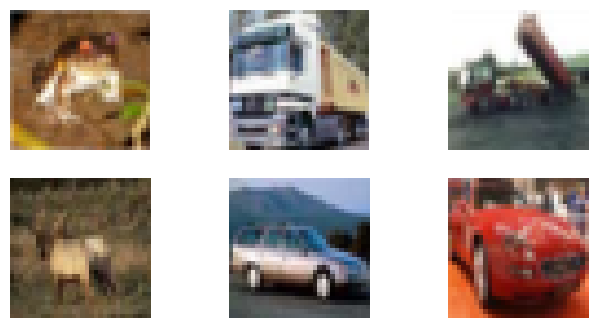

In [4]:
plt.figure(figsize=(8,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_train[i])
    plt.axis("off")
plt.show()

In [5]:
modelo_base = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

modelo_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
hist_base = modelo_base.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 62s 48ms/step - accuracy: 0.4561 - loss: 1.5080 - val_accuracy: 0.5422 - val_loss: 1.2873
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 46ms/step - accuracy: 0.5900 - loss: 1.1699 - val_accuracy: 0.6185 - val_loss: 1.0932
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 57s 45ms/step - accuracy: 0.6414 - loss: 1.0280 - val_accuracy: 0.6477 - val_loss: 1.0163
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 83s 46ms/step - accuracy: 0.6732 - loss: 0.9377 - val_accuracy: 0.6559 - val_loss: 0.9990
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.6980 - loss: 0.8701 - val_accuracy: 0.6585 - val_loss: 0.9935


In [7]:
loss_base, acc_base = modelo_base.evaluate(x_test, y_test)

print("Modelo base:", acc_base)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6575 - loss: 1.0092
Modelo base: 0.6575000286102295


In [8]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

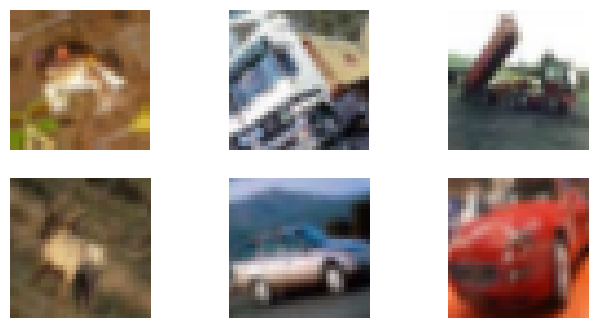

In [9]:
plt.figure(figsize=(8,4))

for i in range(6):
    img = x_train[i]
    img = np.expand_dims(img, axis=0)
    aug_img = data_aug(img)

    plt.subplot(2,3,i+1)
    plt.imshow(aug_img[0])
    plt.axis("off")

plt.show()

In [11]:
modelo_aug = models.Sequential([
    data_aug,

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

modelo_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
hist_aug = modelo_aug.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 75s 59ms/step - accuracy: 0.4073 - loss: 1.6403 - val_accuracy: 0.4894 - val_loss: 1.4331
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 79s 56ms/step - accuracy: 0.5119 - loss: 1.3655 - val_accuracy: 0.5187 - val_loss: 1.3727
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 72s 57ms/step - accuracy: 0.5552 - loss: 1.2603 - val_accuracy: 0.5907 - val_loss: 1.1835
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 69s 55ms/step - accuracy: 0.5746 - loss: 1.2025 - val_accuracy: 0.5815 - val_loss: 1.2006
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.5868 - loss: 1.1643 - val_accuracy: 0.6163 - val_loss: 1.1247


In [13]:
loss_aug, acc_aug = modelo_aug.evaluate(x_test, y_test)

print("Modelo con augmentation:", acc_aug)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6184 - loss: 1.0979
Modelo con augmentation: 0.618399977684021


In [14]:
x_train_tl = tf.image.resize(x_train[:10000], (96,96))
y_train_tl = y_train[:10000]

x_test_tl = tf.image.resize(x_test[:2000], (96,96))
y_test_tl = y_test[:2000]

In [15]:
base_model = MobileNetV2(
    input_shape=(96,96,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
modelo_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

modelo_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
hist_tl = modelo_tl.fit(
    x_train_tl, y_train_tl,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 78s 286ms/step - accuracy: 0.6665 - loss: 0.9771 - val_accuracy: 0.7580 - val_loss: 0.7294
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 309ms/step - accuracy: 0.7815 - loss: 0.6224 - val_accuracy: 0.7475 - val_loss: 0.7511
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 302ms/step - accuracy: 0.8149 - loss: 0.5183 - val_accuracy: 0.7730 - val_loss: 0.6935
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 69s 275ms/step - accuracy: 0.8330 - loss: 0.4674 - val_accuracy: 0.7815 - val_loss: 0.6646
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 69s 275ms/step - accuracy: 0.8676 - loss: 0.3836 - val_accuracy: 0.7825 - val_loss: 0.6823


In [18]:
loss_tl, acc_tl = modelo_tl.evaluate(x_test_tl, y_test_tl)

print("Transfer Learning:", acc_tl)

63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.7730 - loss: 0.6924
Transfer Learning: 0.7730000019073486


## Análisis

El modelo base aprende directamente de los datos originales.

El modelo con Data Augmentation muestra mejor capacidad de generalización, ya que se entrena con variaciones de las imágenes.

El modelo con Transfer Learning aprovecha conocimiento previo, lo que permite obtener resultados más robustos con menos datos.

## Conclusiones

1. El Data Augmentation mejora la generalización al aumentar la diversidad de datos.
2. El modelo base puede sobreajustarse más fácilmente.
3. El Transfer Learning permite aprovechar modelos ya entrenados.
4. Cada técnica tiene ventajas dependiendo del tamaño del dataset.